# Install Library

In [ ]:
!pip -q install tensorflow

# Import Library

In [ ]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf

warnings.filterwarnings("ignore")

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    GRU,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Mount Gdrive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
TRAIN_PATH = "/content/drive/MyDrive/ABSA_Training_New/train.csv"
VALID_PATH = "/content/drive/MyDrive/ABSA_Training_New/validation.csv"
TEST_PATH = "/content/drive/MyDrive/ABSA_Training_New/test.csv"

train_df = pd.read_csv(TRAIN_PATH)
valid_df = pd.read_csv(VALID_PATH)
test_df = pd.read_csv(TEST_PATH)

print(train_df.shape)
print(valid_df.shape)
print(test_df.shape)

(6368, 6)
(796, 6)
(797, 6)


In [ ]:
train_df = train_df.dropna(subset=["sentiment"])
valid_df = valid_df.dropna(subset=["sentiment"])
test_df = test_df.dropna(subset=["sentiment"])

In [ ]:
train_df["input_text"] = (
    train_df["aspect"] + " : " + train_df["text"]
)

valid_df["input_text"] = (
    valid_df["aspect"] + " : " + valid_df["text"]
)

test_df["input_text"] = (
    test_df["aspect"] + " : " + test_df["text"]
)

In [ ]:
MAX_WORDS = 30000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(
    train_df["input_text"]
)

In [ ]:
X_train = tokenizer.texts_to_sequences(
    train_df["input_text"]
)

X_valid = tokenizer.texts_to_sequences(
    valid_df["input_text"]
)

X_test = tokenizer.texts_to_sequences(
    test_df["input_text"]
)

In [ ]:
MAX_LEN = 100

X_train = pad_sequences(
    X_train,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_valid = pad_sequences(
    X_valid,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

In [ ]:
y_train = train_df["sentiment_label"].values
y_valid = valid_df["sentiment_label"].values
y_test = test_df["sentiment_label"].values

# GRU Model

In [ ]:
VOCAB_SIZE = min(
    MAX_WORDS,
    len(tokenizer.word_index) + 1
)

model = Sequential([
    tf.keras.layers.Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=300
    ),

    Bidirectional(
    GRU(
        128,
        return_sequences=False
        )
    ),

    Dropout(0.5),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        3,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 300)       │     2,643,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       330,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,990,183 (11.41 MB)

 Trainable params: 2,990,183 (11.41 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.5636395822269428), np.int64(1): np.float64(8.918767507002801), np.int64(2): np.float64(0.8979131415679639)}


In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 98s 468ms/step - accuracy: 0.8241 - loss: 0.4898 - val_accuracy: 0.8970 - val_loss: 0.3414
Epoch 2/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 101s 507ms/step - accuracy: 0.9180 - loss: 0.2596 - val_accuracy: 0.8756 - val_loss: 0.3721
Epoch 3/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 120s 600ms/step - accuracy: 0.9432 - loss: 0.1818 - val_accuracy: 0.8970 - val_loss: 0.3227
Epoch 4/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 116s 475ms/step - accuracy: 0.9634 - loss: 0.1175 - val_accuracy: 0.9108 - val_loss: 0.4027
Epoch 5/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 95s 475ms/step - accuracy: 0.9720 - loss: 0.0933 - val_accuracy: 0.9033 - val_loss: 0.3874
Epoch 6/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 130s 416ms/step - accuracy: 0.9769 - loss: 0.0775 - val_accuracy: 0.9008 - val_loss: 0.3519


In [ ]:
# PREDICTION

y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step


In [ ]:
# EVALUATION

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.8895859473023839
Precision: 0.8845439397192726
Recall : 0.8895859473023839
F1 Score : 0.885006861293444


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       471
           1       0.60      0.30      0.40        30
           2       0.86      0.91      0.88       296

    accuracy                           0.89       797
   macro avg       0.79      0.71      0.73       797
weighted avg       0.88      0.89      0.89       797



In [ ]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[432,   5,  34],
       [ 13,   9,   8],
       [ 27,   1, 268]])

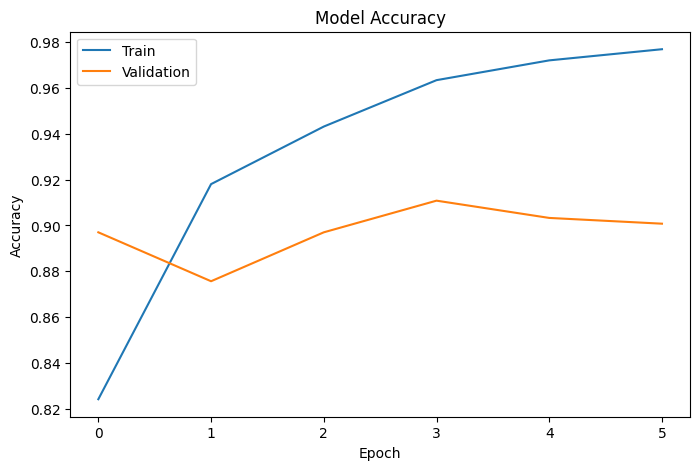

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

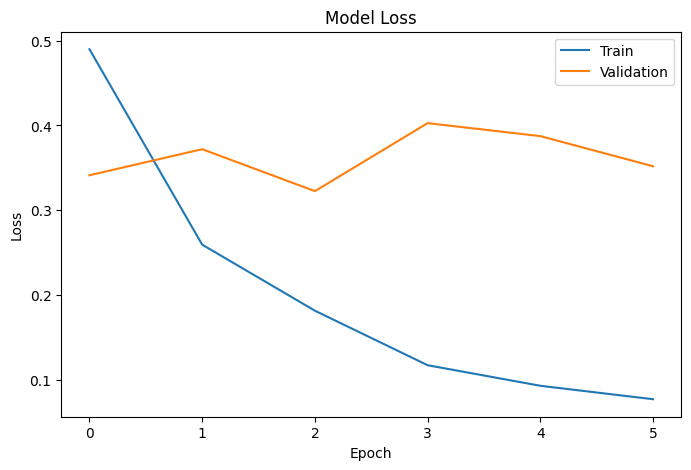

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

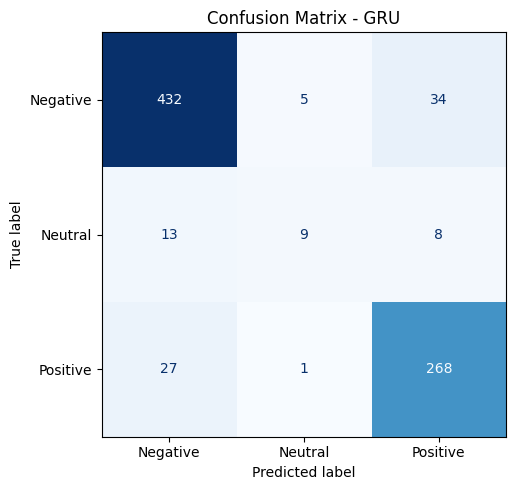

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Neutral", "Positive"]  # sesuaikan dengan mapping LabelEncoder
)

fig, ax = plt.subplots(figsize=(6,5))
disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - GRU")
plt.tight_layout()
plt.show()